# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks II: AlexNet

<br/>
Jiří Fejlek

2026-02-06
<br/>

## Table of Contents

- [AlexNet](#alexnet)
    - [Training AlexNet on Fashion-MNIST](#alexnet_fashion_mnist)
    - [Training AlexNet on CIFAR-10](#alexnet_CIFAR_10)
- [Data Augmentation](#data_aug)
- [References](#references)


In this smaller project, we are moving over 10 years from LeNet to AlexNet from 2012 [[1](#1)], a revolutionary neural network at the time due to its unprecedented size, made possible by training it on GPUs. 


## AlexNet <a class="anchor" id="alexnet"></a>

AlexNet was constructed using the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2010 dataset (AlexNet subsequently won ILSVRC 2012), which consisted of 1.2 million images [[1](#1)]. AlexNet can be implemented in PyTorch as follows [[2](#2)].

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch
from torch import nn

from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1, padding_mode='zeros'),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2, padding_mode='zeros'), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1, padding_mode='zeros'), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1, padding_mode='zeros'), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1, padding_mode='zeros'), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

We observe that AlexNet is structurally similar to LeNet, with some modernizations we already explored in the previous part. The sigmoid activation functions were replaced with ReLUs, and dropout was introduced in the classification layers. Moreover, average pooling is replaced with *max pooling*. We also notice that, unlike LeNet, pooling operations overlap (2x2 kernel with stride 2 in LeNet vs. 3x3 kernel with stride 2 in AlexNet). 

To have a better look at Alexnet, we will use the *layer_summary* function from [[2](#2)].

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

As far as the input is concerned, Alexnet was designed for 227x227 images. 

In [4]:
layer_summary(AlexNet(10),(1, 1, 227, 227))

Conv2d output shape:	 torch.Size([1, 96, 55, 55])
ReLU output shape:	 torch.Size([1, 96, 55, 55])
MaxPool2d output shape:	 torch.Size([1, 96, 27, 27])
Conv2d output shape:	 torch.Size([1, 256, 27, 27])
ReLU output shape:	 torch.Size([1, 256, 27, 27])
MaxPool2d output shape:	 torch.Size([1, 256, 13, 13])
Conv2d output shape:	 torch.Size([1, 384, 13, 13])
ReLU output shape:	 torch.Size([1, 384, 13, 13])
Conv2d output shape:	 torch.Size([1, 384, 13, 13])
ReLU output shape:	 torch.Size([1, 384, 13, 13])
Conv2d output shape:	 torch.Size([1, 256, 13, 13])
ReLU output shape:	 torch.Size([1, 256, 13, 13])
MaxPool2d output shape:	 torch.Size([1, 256, 6, 6])
Flatten output shape:	 torch.Size([1, 9216])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

We observe that AlexNet is *much* wider and deeper than LeNet. We note that in the original paper [[1](#1)], the image size is stated as 224x244 (and this value is often cited in later sources). However, this is a mistake as clarified by one of its authors, Andrej Karpathy (https://en.wikipedia.org/wiki/AlexNet). For images of size 224x224, the number of kernels in the remaining layers no longer matches the sketch in Figure 2 of [[1](#1)]. In addition, this reduced neural network no longer has the "fabled" 60 million parameters (it has about 50 million parameters).

In [5]:
layer_summary(AlexNet(10),(1, 1, 224, 224))

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

### Training AlexNet on Fashion-MNIST <a class="anchor" id="alexnet_fashion_mnist"></a>

We start by training AlexNet on the Fashion-MNIST dataset [[3](#3)]. We will not use the original ImageNet dataset, since it would take unnecessarily long even on today's hardware. To preserve the original AlexNet architecture, we will upscale the Fashion-MNIST images to 227x227. We should note that this is not a good idea in general since it increases the problem's complexity without adding new information [[2](#2)]. 

In [6]:
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([227,227]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

We should note that since we are dealing with relatively large neural networks, we need to keep in mind memory requirements for training and evalutaing neural networks. Alexnet was originally trained using 128 batches on  two GTX 580 with 3GB VRAM each, i.e., 6GB total [[1](#1)]. We will use RTX 4070 Ti with 16GB VRAM and consequently, we doubled the batch size.

In [7]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

Let us initialize AlexNet. We have used "lazy" layers; therefore, we need to evaluate the network on some data.

In [8]:
cuda_device = torch.device('cuda')
AlexNet_cuda = AlexNet(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
AlexNet_cuda(x);

The number of trainable parameters is as follows.

In [9]:
sum(p.numel() for p in AlexNet_cuda.parameters() if p.requires_grad)

58299082

For comparison, LeNet consists of about 60000 parameters. Let us initialize the weights and define the training loop. We should note that we have 58 million parameters (not 60 million, as cited in [[1](#1)]), because we classify images into ten categories rather than the one thousand categories of the Imagenet dataset. Consequently, the last layer of our model is a bit smaller. 

In [10]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)   

In [11]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

For training, we will use the following values of hyperparameters: the momentum of 0.9, the weight decay of 0.001, and the initial learning rate 0.01. 

In [12]:
torch.manual_seed(123)
AlexNet_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(AlexNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, AlexNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1733.8658602237701


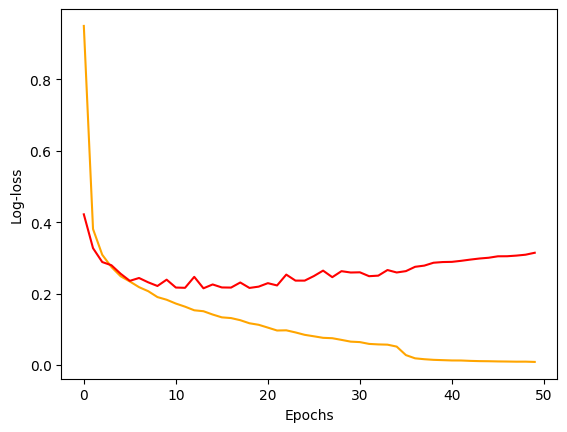

In [13]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

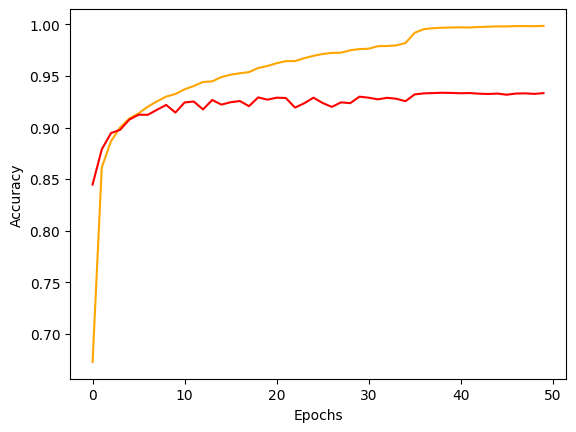

In [14]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

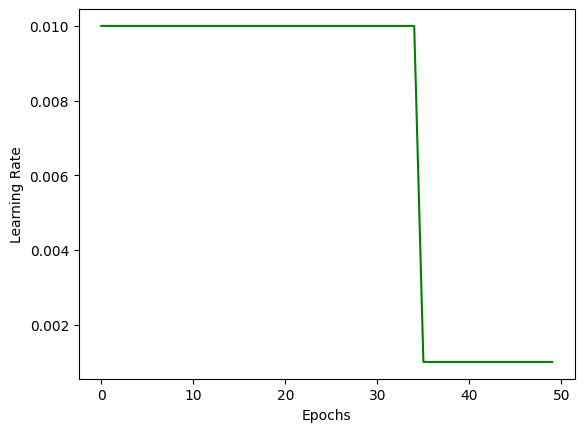

In [15]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [16]:
accu_epochs_train[49]

0.9984666705131531

In [17]:
accu_epochs_test[49]

0.9332999587059021

We achieved almost 100% accuracy on the training set and 93% on the test set, indicating very little overfitting. We should note that this is quite remarkable, since we are using a model with almost 60 million parameters on a dataset of *merely* 60000 images. For comparison, the performance of the unmodified LeNet was 89%. After our modifications (which brought LeNet closer to AlexNet in terms of architecture), we achieved 90% on the test set. 

Full-scale AlexNet is clearly a bit of an overkill for this dataset. Let us try a slightly downscaled version of AlexNet next.

In [18]:
class AlexNet_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net_stack = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=11, stride=1, padding=0, padding_mode='zeros'),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(192, kernel_size=5, padding=2, padding_mode='zeros'), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=3, padding=1, padding_mode='zeros'), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1, padding_mode='zeros'), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1, padding_mode='zeros'), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(1280), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(1280), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [19]:
layer_summary(AlexNet_red(10),(1, 1, 41, 41))

Conv2d output shape:	 torch.Size([1, 64, 31, 31])
ReLU output shape:	 torch.Size([1, 64, 31, 31])
MaxPool2d output shape:	 torch.Size([1, 64, 15, 15])
Conv2d output shape:	 torch.Size([1, 192, 15, 15])
ReLU output shape:	 torch.Size([1, 192, 15, 15])
MaxPool2d output shape:	 torch.Size([1, 192, 7, 7])
Conv2d output shape:	 torch.Size([1, 256, 7, 7])
ReLU output shape:	 torch.Size([1, 256, 7, 7])
Conv2d output shape:	 torch.Size([1, 256, 7, 7])
ReLU output shape:	 torch.Size([1, 256, 7, 7])
Conv2d output shape:	 torch.Size([1, 192, 7, 7])
ReLU output shape:	 torch.Size([1, 192, 7, 7])
MaxPool2d output shape:	 torch.Size([1, 192, 3, 3])
Flatten output shape:	 torch.Size([1, 1728])
Linear output shape:	 torch.Size([1, 1280])
ReLU output shape:	 torch.Size([1, 1280])
Dropout output shape:	 torch.Size([1, 1280])
Linear output shape:	 torch.Size([1, 1280])
ReLU output shape:	 torch.Size([1, 1280])
Dropout output shape:	 torch.Size([1, 1280])
Linear output shape:	 torch.Size([1, 10])


We kept the convolution kernel sizes the same. However, we reduced the stride in the first layer to one. We also reduced the number of kernels in each layer. The inputs will be images 41x41, which were selected to ensure that output images after any convolution that are computed as
$$ n_\text{out} =  \frac{n_\text{in} + 2\cdot \text{padding} - \text{kernel}}{\text{stride}} + 1$$
are always integers, i.e., we are not wasting pixels.

In [20]:
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([41,41]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = True) 

In [21]:
AlexNet_red_cuda = AlexNet_red(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
AlexNet_red_cuda(x);

In [22]:
sum(p.numel() for p in AlexNet_red_cuda.parameters() if p.requires_grad)

5656074

We observe that the number of parameters is reduced from over 58 million to about 5.5 million.

In [23]:
torch.manual_seed(123)
AlexNet_red_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(AlexNet_red_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda =  torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, AlexNet_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

841.9765627384186


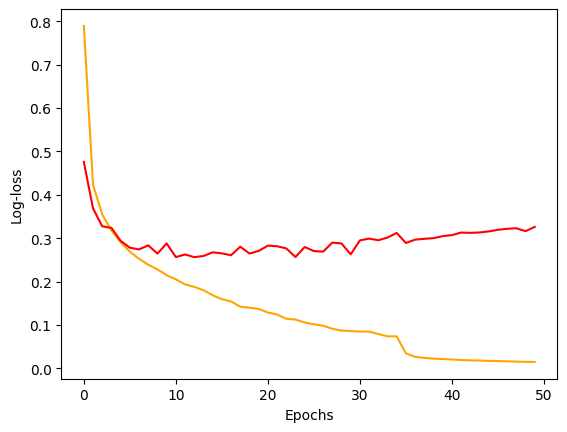

In [24]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

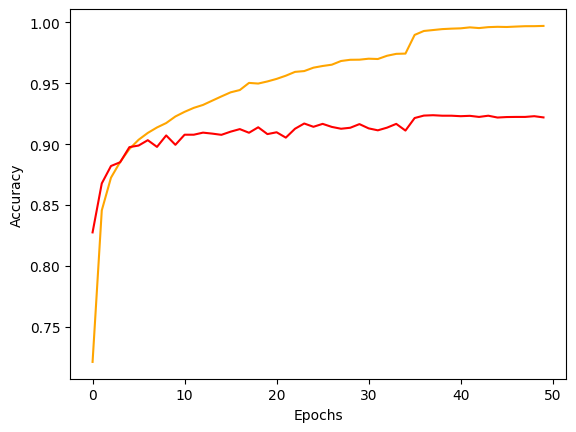

In [25]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

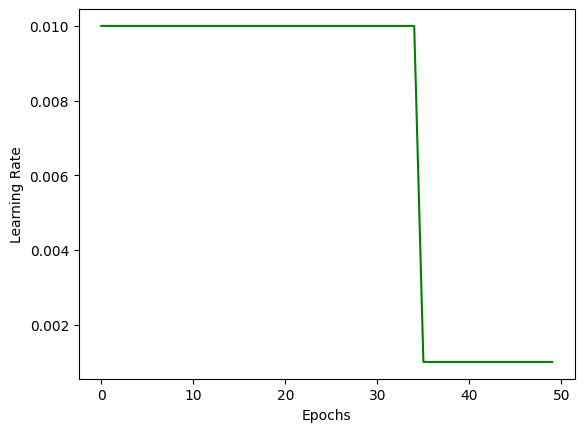

In [26]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [27]:
accu_epochs_train[49]

0.9971166849136353

In [28]:
accu_epochs_test[49]

0.921999990940094

We achieved a slightly worse 92% accuracy with a significantly smaller neural network. 

### Training AlexNet on CIFAR-10 <a class="anchor" id="alexnet_CIFAR_10"></a>

Let us move on to the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html), which consists of 60000 32x32 color images from ten categories. Let us first normalize the images; we will compute the sample mean and variance for the dataset.

In [29]:
cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True)

sumx_all = 0
sumx_sq_all = 0

for i in range(cifar10_train.__len__()):
    sumx_all = sumx_all + torchvision.transforms.ToTensor()(cifar10_train.__getitem__(i)[0]).sum(axis = [1,2])
    sumx_sq_all = sumx_sq_all + ((torchvision.transforms.ToTensor()(cifar10_train.__getitem__(i)[0]))**2).sum(axis = [1,2])

In [30]:
n = (32**2*cifar10_train.__len__())
sumx_all/n

tensor([0.4914, 0.4822, 0.4465])

In [31]:
((sumx_sq_all - (sumx_all**2)/n)/(n-1)).sqrt()

tensor([0.2470, 0.2435, 0.2616])

We will again upsample images to 227x227.

In [32]:
transforms_cifar10 =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([227,227]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False) 

Let us train the AlexNet model. We will use an initial learning rate of 0.001, since 0.01 proved to be too high.

In [33]:
cuda_device = torch.device('cuda')
AlexNet2_cuda = AlexNet(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
AlexNet2_cuda(x);

In [34]:
torch.manual_seed(123)
AlexNet2_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(AlexNet2_cuda.parameters(), lr = 0.001, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma=0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, AlexNet2_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2336.7491612434387


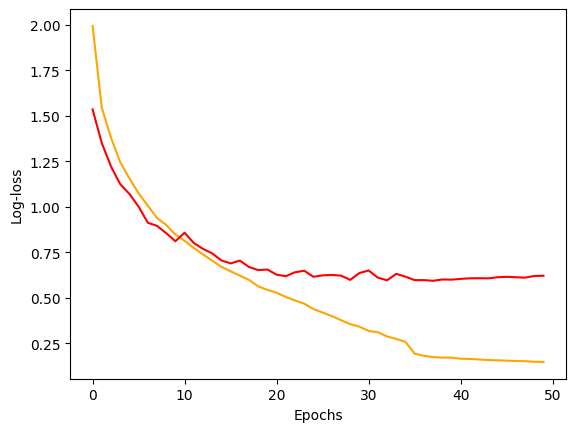

In [35]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

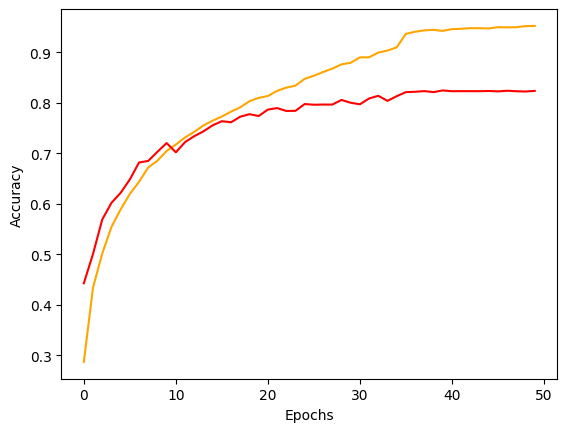

In [36]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

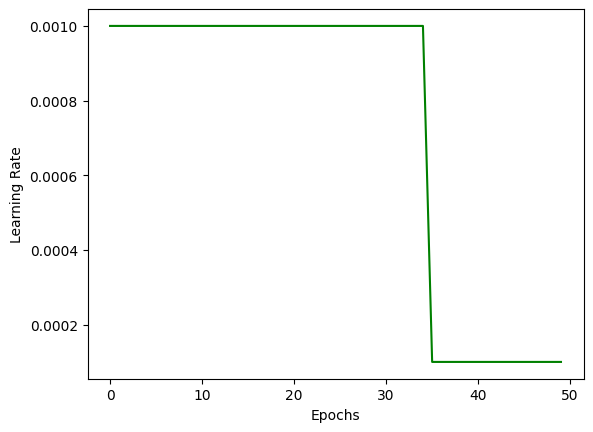

In [37]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [38]:
accu_epochs_train[49]

0.9526000022888184

In [39]:
accu_epochs_test[49]

0.8238999843597412

For the CIFAR-10, the complexity of AlexNet seems to pay off. The accuracy on the test set is significantly higher (over 82%) than we have obtained for the LesNet model (65%). Still, let us also try our downscaled AlexNet-inspired model.

In [40]:
transforms_cifar10 =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([41,41]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = True) 

In [41]:
AlexNet_red_cuda2 = AlexNet_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
AlexNet_red_cuda2(x);

In [42]:
torch.manual_seed(123)
AlexNet_red_cuda2.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(AlexNet_red_cuda2.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma=0.1)
cross_entropy_loss = nn.CrossEntropyLoss()


n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, AlexNet_red_cuda2, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1768.3450775146484


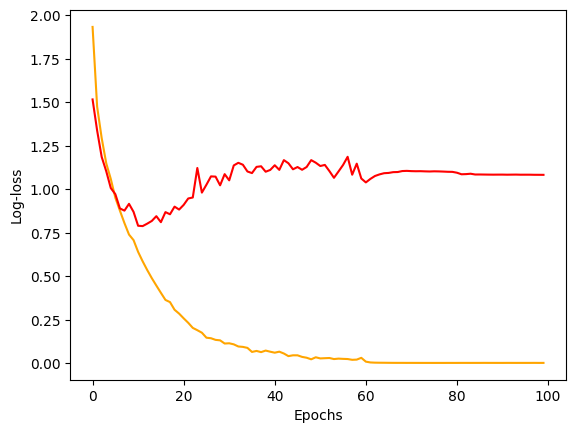

In [43]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

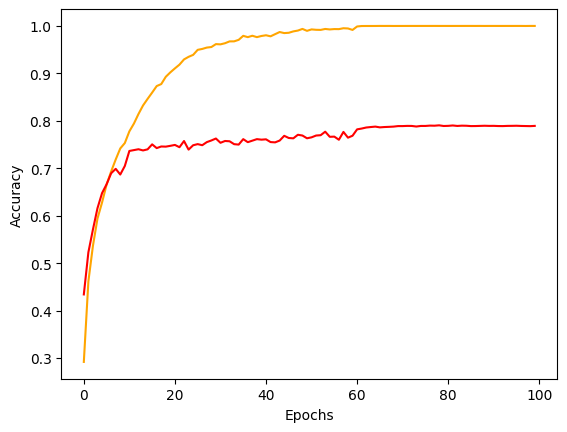

In [44]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

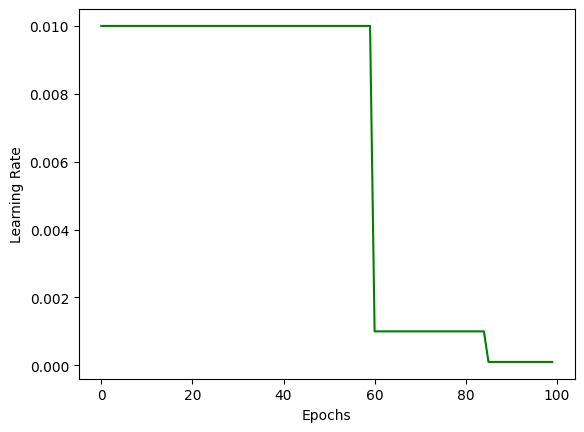

In [45]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [46]:
accu_epochs_train[49]

0.9896399974822998

In [47]:
accu_epochs_test[49]

0.7631999850273132

The performance did deteriorate, but we can try to do better.

## Data Augmentation <a class="anchor" id="data_aug"></a>

Data augmentation is a set of techniques that train the model on altered versions of the original training dataset [[2](#2)] to increase the model's robustness to new data. For example, if we flip an image horizontally (via *torchvision.transforms.RandomHorizontalFlip*), we get a slightly different image that still belongs to the same class.

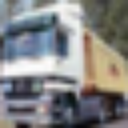

In [48]:
cifar10_set = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True)
torchvision.transforms.RandomHorizontalFlip(0.0)(torchvision.transforms.Resize([128,128])(cifar10_set.__getitem__(1)[0]))

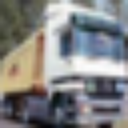

In [49]:
torchvision.transforms.RandomHorizontalFlip(1.0)(torchvision.transforms.Resize([128,128])(cifar10_set.__getitem__(1)[0]))

Similarly, we can extract a random, slightly smaller subimage of the original image.

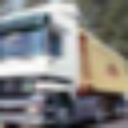

In [50]:
torchvision.transforms.Resize([128,128])(torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8,1.0])(cifar10_set.__getitem__(1)[0]))

By using data augmentation, we effectively enlarge our training dataset and, hopefully, make the classification algorithm more robust to slight data alterations.

Let us implement a simple data augmentation technique that uses randomized horizontal flipping and cropping (we could also consider random rotations, perspective shifts, brightness and contrast adjustments, color hue adjustments, random blurring, etc., see https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html for more details). 

We should note that random scale that is greater than one, is reduced back to one, i.e., increasing the upper bound above one merely increases probability of picking the scale one. 

In [51]:
transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([41,41]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[41,41], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([41,41]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = True) 

In [52]:
torch.manual_seed(123)
AlexNet_red_cuda2.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(AlexNet_red_cuda2.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60,85], gamma=0.1)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, AlexNet_red_cuda2, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3147.507922887802


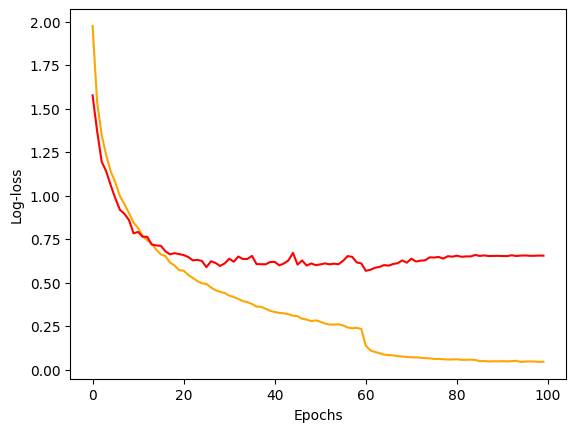

In [53]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

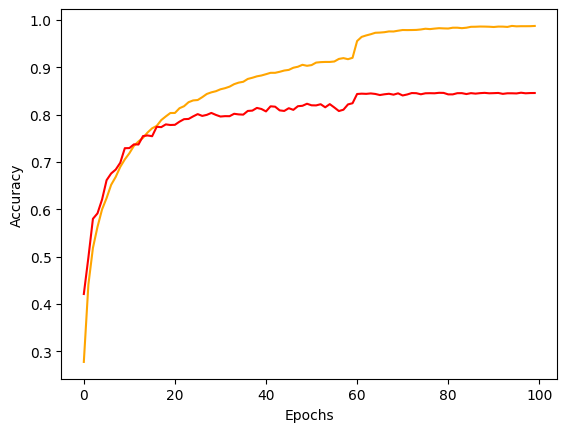

In [54]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

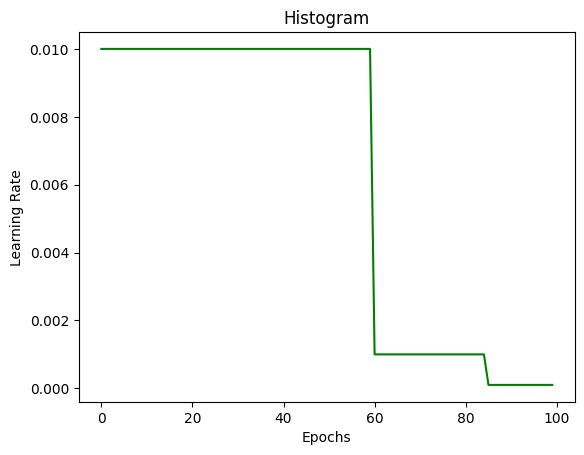

In [55]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [56]:
accu_epochs_train[49]

0.9031999707221985

In [57]:
accu_epochs_test[49]

0.8229999542236328

We improved the accuracy on the test dataset by about 6% and we matched with our significantly smaller network the performance of AlexNet we have observed earlier.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> KRIZHEVSKY, Alex; SUTSKEVER, Ilya; HINTON, Geoffrey E. Imagenet classification with deep convolutional neural networks. *Advances in neural information processing systems*, 2012, 25.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.